# Cross-Domain Robustness Test — WUSTL IIoT 2021

Test khả năng tổng quát hóa của latent space 64-dim khi dataset có **features hoàn toàn khác** (Argus bidirectional flow vs NetFlow).

**2 kịch bản test:**
- **Test 1 — Zero-Shot**: Dùng extractor random-initialized (không train), chạy qua frozen pipeline. Kết quả dự kiến thấp → chứng minh cần alignment.
- **Test 2 — Semi-Supervised (1%, 3%, 5%)**: Train WUSTLFeatureExtractor với supervised + MMD losses, init từ đầu (không có zero-pad giống UQ v2). Kết quả dự kiến cải thiện nhiều → chứng minh latent space works.

**Session grouping**: `(Sport, Dport)` — nhất quán với UQ `(L4_SRC_PORT, L4_DST_PORT)` và CIC `(Source Port, Destination Port)`. Sport/Dport **không** dùng làm feature.

**Frozen pipeline** (không đổi weights):  
`WUSTLFeatureExtractor(41→64) → [CNN_LSTM | BiLSTM | Transformer](64→5) → Meta-Learner`

In [1]:
import sys, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, TensorDataset
from copy import deepcopy
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from feature_alignment import (
    FeatureAligner, UQFeatureExtractor, TimeSeriesDataset,
    create_sessions_and_windows, fit_scaler, apply_scaler, encode_labels,
    create_dataloaders,
    DEVICE, LATENT_DIM, WINDOW_SIZE, STRIDE, NUM_CLASSES, UNIFIED_CLASSES,
    UQ_LABEL_MAP, UQ_SESSION_COLS,
)

# ── Paths & directories ─────────────────────────────────────────
BASE_DIR  = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
MODEL_DIR = os.path.join(BASE_DIR, "Project", "Model", "Model_2017_IRM")

WUSTL_DATA_PATH = os.path.join(BASE_DIR, "Dataset", "wustl_balanced_dataset.parquet")
V3_DATA_PATH    = os.path.join(BASE_DIR, "Dataset", "nf_uq_balanced_dataset_v3.parquet")

# ── Model names ─────────────────────────────────────────────────
MODEL_NAMES = ['cnn_lstm', 'tl_bilstm', 'transformer']
BATCH_SIZE  = 256
N_CLASSES   = NUM_CLASSES           # alias (5 unified classes)

# ── WUSTL session cols — chỉ dùng Sport + Dport để group session,
#    giống UQ dùng L4_SRC_PORT + L4_DST_PORT, CIC dùng Source/Destination Port.
#    SrcAddr, DstAddr, StartTime là metadata, Proto là feature số.
WUSTL_SESSION_COLS  = ['Sport', 'Dport']      # group key (excluded from features)
WUSTL_SORT_COL      = 'StartTime'             # sort within each session
WUSTL_META_COLS     = {'SrcAddr', 'DstAddr', 'StartTime', 'Label'}  # drop entirely
WUSTL_CLASSES       = ['Benign', 'BruteForce', 'DoS']  # 4 of 5
WUSTL_CLASS_INDICES = [UNIFIED_CLASSES.index(c) for c in WUSTL_CLASSES]

# ── Semi-supervised hyper-params ─────────────────────────────────
LABEL_FRACTIONS = [0.01, 0.03, 0.05]
SEMI_EPOCHS     = 120
SEMI_LR         = 5e-4
SEMI_PATIENCE   = 8
MMD_BATCH       = 256
LAMBDA_MMD      = 1.0
LAMBDA_CORAL    = 0.5

# ── Results accumulator ──────────────────────────────────────────
all_results: dict = {}

print(f"Device          : {DEVICE}")
print(f"WUSTL session   : {WUSTL_SESSION_COLS}  (port-pair grouping, same as UQ/CIC)")
print(f"WUSTL classes   : {WUSTL_CLASSES}")
print(f"Unified classes : {UNIFIED_CLASSES}")
print(f"Model Dir       : {MODEL_DIR}")

Device          : cuda
WUSTL session   : ['Sport', 'Dport']  (port-pair grouping, same as UQ/CIC)
WUSTL classes   : ['Benign', 'BruteForce', 'DoS']
Unified classes : ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']
Model Dir       : /home/huyho/earth_predict_env/Project/Model/Model_2017_IRM


In [2]:
# ================================================================
# Model Architectures (identical to Meta_Learner.ipynb)
# ================================================================

class CNN_LSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(latent_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, z):
        x = z.permute(0, 2, 1)
        x = self.cnn(x).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attention(lstm_output), dim=1)
        return (lstm_output * attn_weights).sum(dim=1), attn_weights.squeeze(-1)


class TL_BiLSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=128, num_classes=NUM_CLASSES):
        super().__init__()
        self.bilstm = nn.LSTM(latent_dim, hidden_dim // 2, num_layers=2,
                              batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = TemporalAttention(hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden_dim, num_classes))

    def forward(self, z):
        lstm_out, _ = self.bilstm(z)
        context, _ = self.attention(lstm_out)
        return self.classifier(self.layer_norm(context))


class TransformerClassifier(nn.Module):
    def __init__(self, d_model=LATENT_DIM, nhead=8, num_layers=4,
                 dim_feedforward=256, num_classes=NUM_CLASSES):
        super().__init__()
        self.pos_enc = nn.Parameter(torch.randn(1, WINDOW_SIZE, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(d_model, num_classes))

    def forward(self, z):
        x = z + self.pos_enc[:, :z.size(1), :]
        x = self.layer_norm(self.transformer(x))
        return self.classifier(x.mean(dim=1))


class AlignerWithModel(nn.Module):
    def __init__(self, uq_dim, cic_dim, base_model):
        super().__init__()
        self.aligner = FeatureAligner(uq_dim, cic_dim)
        self.base_model = base_model

    def forward(self, x, dataset_type='uq'):
        z = self.aligner(x, dataset_type)
        return self.base_model(z)

    def predict_proba(self, x, dataset_type='uq'):
        return torch.softmax(self.forward(x, dataset_type), dim=1)


def create_models(uq_dim, cic_dim):
    return {
        'cnn_lstm':   AlignerWithModel(uq_dim, cic_dim, CNN_LSTM()),
        'tl_bilstm':  AlignerWithModel(uq_dim, cic_dim, TL_BiLSTM()),
        'transformer': AlignerWithModel(uq_dim, cic_dim, TransformerClassifier()),
    }

print("Model architectures defined.")

Model architectures defined.


In [3]:
# ================================================================
# Load Frozen Models
# ================================================================
UQ_V3_DIM = 47
CIC_DIM   = 78

frozen_models = create_models(UQ_V3_DIM, CIC_DIM)

for name in MODEL_NAMES:
    path = os.path.join(MODEL_DIR, f"final_{name}.pth")
    state_dict = torch.load(path, map_location=DEVICE, weights_only=True)
    frozen_models[name].load_state_dict(state_dict)
    frozen_models[name].to(DEVICE)
    frozen_models[name].eval()
    frozen_models[name].requires_grad_(False)
    n_params = sum(p.numel() for p in frozen_models[name].parameters())
    print(f"✓ Loaded & frozen {name}: {n_params:,} params")

# Load frozen meta-learner
meta_learner = joblib.load(os.path.join(MODEL_DIR, "meta_learner_lr.pkl"))
print(f"✓ Loaded meta-learner: {type(meta_learner).__name__}")

# Extract frozen UQ Feature Extractor (47-dim → 64-dim, used as MMD reference)
frozen_uq_extractor = frozen_models['cnn_lstm'].aligner.uq_extractor
print(f"✓ Frozen UQ Feature Extractor: input={UQ_V3_DIM} → output={LATENT_DIM}")

# Sanity check
for name, model in frozen_models.items():
    trainable = sum(p.requires_grad for p in model.parameters())
    assert trainable == 0, f"{name} has {trainable} trainable params!"
print("\n✓ All base models and meta-learner are FROZEN.")

✓ Loaded & frozen cnn_lstm: 364,869 params
✓ Loaded & frozen tl_bilstm: 208,646 params
✓ Loaded & frozen transformer: 235,845 params
✓ Loaded meta-learner: LogisticRegression
✓ Frozen UQ Feature Extractor: input=47 → output=64

✓ All base models and meta-learner are FROZEN.


In [4]:
# ================================================================
# Load WUSTL Data + Session Windowing + Scaling + Label Encoding
# ================================================================
def create_wustl_windows(df, feature_cols, session_cols, sort_col,
                          label_col='Label',
                          window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Group flows by (Sport, Dport) — same strategy as UQ (L4_SRC_PORT, L4_DST_PORT)
    and CIC (Source Port, Destination Port).
    Sort by StartTime within each session, then slide a window.
    Short sessions are zero-padded.
    Returns (X, y) as numpy arrays.
    """
    df = df.copy()
    df['_key'] = (df[session_cols[0]].astype(str) + '_' +
                  df[session_cols[1]].astype(str))
    df = df.sort_values(['_key', sort_col]).reset_index(drop=True)

    X_raw = df[feature_cols].values.astype(np.float32)
    X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
    y_raw = df[label_col].values
    keys  = df['_key'].values

    windows_list, labels_list = [], []
    n_features = X_raw.shape[1]

    prev_key  = None
    seg_start = 0

    def _flush(start, end):
        sx = X_raw[start:end]
        sy = y_raw[start:end]
        n  = len(sx)
        if n < window_size:
            pad = np.zeros((window_size, n_features), dtype=np.float32)
            pad[:n] = sx
            windows_list.append(pad)
            vals, cnts = np.unique(sy, return_counts=True)
            labels_list.append(vals[np.argmax(cnts)])
        else:
            for s in range(0, n - window_size + 1, stride):
                window = sx[s:s + window_size]
                wy     = sy[s:s + window_size]
                windows_list.append(window)
                vals, cnts = np.unique(wy, return_counts=True)
                labels_list.append(vals[np.argmax(cnts)])

    for i, k in enumerate(keys):
        if k != prev_key:
            if prev_key is not None:
                _flush(seg_start, i)
            prev_key  = k
            seg_start = i
    _flush(seg_start, len(keys))

    return np.array(windows_list, dtype=np.float32), np.array(labels_list)


# ---------- Load balanced parquet ----------
wustl_df = pd.read_parquet(WUSTL_DATA_PATH)
print(f"WUSTL parquet loaded: {wustl_df.shape}")
print("Label distribution:\n", wustl_df['Label'].value_counts().to_string())

# Feature columns:
#   Drop metadata (SrcAddr, DstAddr, StartTime, Label) AND session keys (Sport, Dport)
#   Sport/Dport are used only for grouping, NOT as input features — same convention as UQ/CIC
_drop_for_features = WUSTL_META_COLS | set(WUSTL_SESSION_COLS)  # {'SrcAddr','DstAddr','StartTime','Label','Sport','Dport'}
wustl_feature_cols = [c for c in wustl_df.columns if c not in _drop_for_features]
WUSTL_N_FEATURES   = len(wustl_feature_cols)
print(f"\nSession key cols (excluded from features): {WUSTL_SESSION_COLS}")
print(f"Feature columns ({WUSTL_N_FEATURES}): {wustl_feature_cols[:5]} ... {wustl_feature_cols[-3:]}")

# ---------- Session windowing ----------
print("\nCreating session windows (this may take ~30 s)...")
wustl_windows, wustl_window_labels = create_wustl_windows(
    wustl_df, wustl_feature_cols,
    session_cols=WUSTL_SESSION_COLS,   # ['Sport', 'Dport']
    sort_col=WUSTL_SORT_COL,           # 'StartTime'
)
print(f"Windows shape : {wustl_windows.shape}")
print(f"Label distribution after windowing:")
unique, counts = np.unique(wustl_window_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")

# ---------- Scale features ----------
scaler = StandardScaler()
n_w, t_len, n_f = wustl_windows.shape
wustl_windows_flat   = wustl_windows.reshape(-1, n_f)
wustl_windows_scaled = scaler.fit_transform(wustl_windows_flat).reshape(n_w, t_len, n_f)
wustl_windows_scaled = wustl_windows_scaled.astype(np.float32)
print("\nScaling done.")

# ---------- Encode labels ----------
le = LabelEncoder()
le.fit(UNIFIED_CLASSES)                                        # 5 unified classes
wustl_labels_encoded  = le.transform(wustl_window_labels)
WUSTL_PRESENT_CLASSES = sorted(set(wustl_labels_encoded.tolist()))  # 4 classes
print(f"Class indices present in WUSTL: {WUSTL_PRESENT_CLASSES}")
print(f"Class names: {[le.inverse_transform([i])[0] for i in WUSTL_PRESENT_CLASSES]}")

# ---------- Train / Eval split (70 / 30) ----------
wustl_X_main, wustl_X_eval, wustl_y_main, wustl_y_eval = train_test_split(
    wustl_windows_scaled, wustl_labels_encoded,
    test_size=0.30, stratify=wustl_labels_encoded, random_state=42
)
print(f"\nTrain pool: {wustl_X_main.shape[0]} | Eval: {wustl_X_eval.shape[0]}")

WUSTL parquet loaded: (15000, 47)
Label distribution:
 Label
BruteForce    5000
DoS           5000
Benign        5000

Session key cols (excluded from features): ['Sport', 'Dport']
Feature columns (41): ['Mean', 'SrcPkts', 'DstPkts', 'TotPkts', 'DstBytes'] ... ['sTos', 'SrcJitAct', 'DstJitAct']

Creating session windows (this may take ~30 s)...
Windows shape : (14136, 30, 41)
Label distribution after windowing:
  Benign: 4243
  BruteForce: 4998
  DoS: 4895

Scaling done.
Class indices present in WUSTL: [0, 1, 3]
Class names: [np.str_('Benign'), np.str_('BruteForce'), np.str_('DoS')]

Train pool: 9895 | Eval: 4241


In [5]:
# ================================================================
# Build V3 Reference Embeddings  (used as MMD anchor for WUSTL)
# ================================================================
from feature_alignment import prepare_dataset as fa_prepare_dataset

print("Loading UQ-v3 windows for reference embeddings (this may take 1–2 min)…")
v3_windows_scaled, v3_labels_encoded, v3_scaler, _, v3_n_feat = fa_prepare_dataset('uq')
print(f"UQ-v3 windows: {v3_windows_scaled.shape}")   # (N, T=30, D=47)

REF_SAMPLE = min(15_000, len(v3_windows_scaled))
rng = np.random.default_rng(42)
ref_idx = rng.choice(len(v3_windows_scaled), REF_SAMPLE, replace=False)
v3_ref_windows = v3_windows_scaled[ref_idx]           # (N, 30, 47)
v3_ref_labels  = v3_labels_encoded[ref_idx]

# ---------- Extract 64-dim reference embeddings ----------
print(f"\nExtracting reference embeddings from {REF_SAMPLE} V3 windows…")
frozen_uq_extractor.eval()
frozen_uq_extractor.to(DEVICE)
ref_emb_parts = []

with torch.no_grad():
    ds     = TimeSeriesDataset(v3_ref_windows, v3_ref_labels, 'uq')
    loader = DataLoader(ds, batch_size=512, shuffle=False)
    for x, _, _ in loader:
        x   = x.to(DEVICE)
        emb = frozen_uq_extractor(x)            # (B, T=30, 64)
        ref_emb_parts.append(emb.cpu())

ref_embeddings      = torch.cat(ref_emb_parts, dim=0)        # (N, 30, 64)
ref_embeddings_flat = ref_embeddings.reshape(-1, LATENT_DIM)  # (N*30, 64)

print(f"Reference embeddings  : {ref_embeddings.shape}")
print(f"Flattened for MMD     : {ref_embeddings_flat.shape}")
print(f"Mean ± Std            : {ref_embeddings_flat.mean():.4f} ± {ref_embeddings_flat.std():.4f}")

# Keep full V3 windows for the MMD pass in semi-supervised training
v3_full_windows = v3_windows_scaled
v3_full_labels  = v3_labels_encoded

Loading UQ-v3 windows for reference embeddings (this may take 1–2 min)…
[UQ] Loaded 1388150 flows, 47 features
[UQ] Label distribution:
Label
Benign          399999
DoS             300000
DDoS            300000
BruteForce      199999
Infiltration    188152
[UQ] Created 186005 windows of shape (186005, 30, 47)
[UQ] Feature dim: 47, Latent target: 64
UQ-v3 windows: (186005, 30, 47)

Extracting reference embeddings from 15000 V3 windows…
Reference embeddings  : torch.Size([15000, 30, 64])
Flattened for MMD     : torch.Size([450000, 64])
Mean ± Std            : 0.0023 ± 0.0225


In [6]:
# ================================================================
# WUSTL Feature Extractor + Loss Functions
# ================================================================
class WUSTLFeatureExtractor(nn.Module):
    """
    Maps WUSTL Argus-flow features → shared latent space (LATENT_DIM).
    Mirrors UQv2FeatureExtractor: handles both (B, T, D) windows
    and (B, D) flat input for MMD batches.
    """
    def __init__(self, input_dim, hidden_dim=128, output_dim=LATENT_DIM, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        if x.dim() == 2:                        # (B, D) → (B, LATENT_DIM)
            return self.net(x)
        B, T, D = x.shape                       # (B, T, D) window
        out = self.net(x.reshape(B * T, D))     # (B*T, LATENT_DIM)
        return out.reshape(B, T, LATENT_DIM)    # (B, T, LATENT_DIM)


# ── MMD Loss (Gaussian RBF kernel) ───────────────────────────────
def gaussian_kernel(x, y, sigmas=(0.1, 0.5, 1.0, 2.0, 5.0, 10.0)):
    xx = (x * x).sum(dim=1, keepdim=True)
    yy = (y * y).sum(dim=1, keepdim=True)
    dist_sq = torch.clamp(xx + yy.T - 2.0 * (x @ y.T), min=0.0)
    k = torch.zeros_like(dist_sq)
    for s in sigmas:
        k = k + torch.exp(-dist_sq / (2.0 * s ** 2))
    return k / len(sigmas)


def mmd_loss(source, target):
    n, m = len(source), len(target)
    k_ss = gaussian_kernel(source, source)
    k_tt = gaussian_kernel(target, target)
    k_st = gaussian_kernel(source, target)
    return k_ss.sum()/(n*n) + k_tt.sum()/(m*m) - 2.0*k_st.sum()/(n*m)


# ── CORAL Loss ────────────────────────────────────────────────────
class CORALLoss(nn.Module):
    def forward(self, source, target):
        d  = source.size(1)
        cs = self._cov(source)
        ct = self._cov(target)
        return ((cs - ct) ** 2).sum() / (4.0 * d * d)

    @staticmethod
    def _cov(x):
        n = x.size(0)
        c = x - x.mean(0, keepdim=True)
        return (c.T @ c) / max(n - 1, 1)

coral_loss_fn = CORALLoss()

print(f"WUSTLFeatureExtractor: {WUSTL_N_FEATURES} → 128 → BN → ReLU → Dropout(0.3) → {LATENT_DIM} → BN → ReLU")
print(f"mmd_loss + CORALLoss  : defined")
print(f"Latent dim target     : {LATENT_DIM}")

WUSTLFeatureExtractor: 41 → 128 → BN → ReLU → Dropout(0.3) → 64 → BN → ReLU
mmd_loss + CORALLoss  : defined
Latent dim target     : 64


In [7]:
# ================================================================
# Test 1 — Zero-Shot Evaluation  (random-init WUSTL extractor)
# ================================================================
# WUSTL has 42 Argus-flow features vs. UQ-v3's 47 NetFlow features.
# No structural overlap → zero-padding is meaningless.
# We use a RANDOMLY INITIALISED WUSTLFeatureExtractor to measure
# how well the frozen downstream stack handles completely unseen
# feature geometry without any adaptation.
# ================================================================

@torch.no_grad()
def predict_with_wustl_extractor(X_windows, extractor, batch_size=256):
    """
    Pipeline:
      WUSTL windows (N, T, F)
        → WUSTLFeatureExtractor → (N, T, LATENT_DIM)
        → Frozen base_model[name]  → softmax probs (N, N_CLASSES)
        × 3 models → X_meta (N, 3*N_CLASSES)
        → meta_learner.predict → y_pred (N,)
    """
    extractor.eval()
    probs_all = {name: [] for name in MODEL_NAMES}

    for s in range(0, len(X_windows), batch_size):
        batch_t = torch.tensor(
            X_windows[s:s + batch_size], dtype=torch.float32
        ).to(DEVICE)                                    # (B, T, F)
        z = extractor(batch_t)                          # (B, T, LATENT_DIM)

        for name, model in frozen_models.items():
            model.base_model.eval()
            logits = model.base_model(z)                # (B, N_CLASSES)
            probs  = torch.softmax(logits, dim=1)
            probs_all[name].append(probs.cpu().numpy())

    stacked = {name: np.vstack(probs_all[name]) for name in MODEL_NAMES}
    X_meta  = np.hstack([stacked[n] for n in MODEL_NAMES])  # (N, 3*N_CLASSES)
    return meta_learner.predict(X_meta)


def evaluate_wustl(y_true, y_pred, label=''):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted',
                    labels=WUSTL_PRESENT_CLASSES, zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted',
                           labels=WUSTL_PRESENT_CLASSES, zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted',
                        labels=WUSTL_PRESENT_CLASSES, zero_division=0)
    class_names = [le.inverse_transform([i])[0] for i in WUSTL_PRESENT_CLASSES]
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        labels=WUSTL_PRESENT_CLASSES,
        zero_division=0,
    )
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n{report}")
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}


# ---------- Random extractor (no training) ----------
torch.manual_seed(42)
wustl_extractor_t1 = WUSTLFeatureExtractor(WUSTL_N_FEATURES).to(DEVICE)
wustl_extractor_t1.eval()
for p in wustl_extractor_t1.parameters():
    p.requires_grad_(False)

print("Running Zero-Shot evaluation on held-out eval set …")
t1_preds = predict_with_wustl_extractor(wustl_X_eval, wustl_extractor_t1)
all_results['zero_shot'] = evaluate_wustl(
    wustl_y_eval, t1_preds,
    label='TEST 1: Zero-Shot (random extractor, no adaptation)'
)

Running Zero-Shot evaluation on held-out eval set …

  TEST 1: Zero-Shot (random extractor, no adaptation)
  Accuracy  : 0.2962
  Precision : 0.0893
  Recall    : 0.2962
  F1-Score  : 0.1372

              precision    recall  f1-score   support

      Benign       0.30      0.99      0.46      1273
  BruteForce       0.00      0.00      0.00      1499
         DoS       0.00      0.00      0.00      1469

   micro avg       0.30      0.30      0.30      4241
   macro avg       0.10      0.33      0.15      4241
weighted avg       0.09      0.30      0.14      4241



## Test 2 — Semi-Supervised Domain Adaptation

Fine-tune a **WUSTL Feature Extractor** using a small fraction of labelled WUSTL windows plus an MMD alignment loss anchored to frozen UQ-v3 embeddings.  
No warm-start is possible here (WUSTL Argus features are structurally unrelated to UQ-v3 NetFlow features).

| Hyper-param | Value |
|---|---|
| Label fractions | 1 %, 3 %, 5 % |
| Epochs | 60 |
| Patience | 8 |
| Adam LR | 5 × 10⁻⁴ |
| MMD batch | 256 |
| Loss | CE + λ_MMD · MMD + λ_CORAL · CORAL |

In [8]:
# ================================================================
# Semi-Supervised Training Function
# ================================================================
def train_wustl_semi_supervised(
    X_pool, y_pool, label_fraction,
    wustl_n_features,
    v3_ref_windows_scaled,   # UQ-v3 windows (N, T, 47) for MMD
    device=DEVICE,
    epochs=SEMI_EPOCHS, lr=SEMI_LR,
    patience=SEMI_PATIENCE,
    init_state=None,          # None → fresh random init
):
    """
    Fine-tune a WUSTLFeatureExtractor with:
      - Supervised CE on 'label_fraction' of X_pool
        → z = extractor(x_lab) (B, T, 64) → frozen base_model → logits → CE
      - Unsupervised MMD: extractor(x_unlab) vs frozen_uq_extractor(x_v3)
      - λ_MMD decays from 1.0 → 0.1 over training

    Returns: (trained extractor, history dict)
    """
    print(f"\n{'='*55}")
    print(f"  Semi-Supervised: {label_fraction*100:.0f}% labelled")
    print(f"{'='*55}")

    # ── Labelled / Unlabelled split ──────────────────────────────
    labeled_idx, unlabeled_idx = train_test_split(
        np.arange(len(y_pool)),
        test_size=1.0 - label_fraction,
        random_state=42,
        stratify=y_pool,
    )
    X_lab, y_lab   = X_pool[labeled_idx],   y_pool[labeled_idx]
    X_unlab        = X_pool[unlabeled_idx]
    print(f"  Labelled:   {len(labeled_idx)} | Unlabelled: {len(unlabeled_idx)}")
    print(f"  Class dist: {np.bincount(y_lab, minlength=N_CLASSES).tolist()}")

    # ── Extractor ────────────────────────────────────────────────
    extractor = WUSTLFeatureExtractor(wustl_n_features).to(device)
    if init_state is not None:
        extractor.load_state_dict(init_state)
        print("  Warm-start from provided state.")

    optimizer  = torch.optim.Adam(extractor.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', patience=3, factor=0.5,
    )

    # Class-weighted CE
    class_counts = np.bincount(y_lab, minlength=N_CLASSES).astype(float)
    cw = 1.0 / (class_counts + 1e-6)
    cw = cw / cw.sum() * N_CLASSES
    criterion_sup = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(cw).to(device)
    )

    # ── Data Loaders ─────────────────────────────────────────────
    lab_ds     = TensorDataset(
        torch.tensor(X_lab,   dtype=torch.float32),
        torch.tensor(y_lab,   dtype=torch.long)
    )
    lab_loader = DataLoader(lab_ds, batch_size=min(64, len(X_lab)),
                            shuffle=True, drop_last=False)

    unlab_ds     = TensorDataset(torch.tensor(X_unlab, dtype=torch.float32))
    unlab_loader = DataLoader(unlab_ds, batch_size=MMD_BATCH,
                              shuffle=True, drop_last=False)

    v3_ds     = TimeSeriesDataset(v3_ref_windows_scaled,
                                  np.zeros(len(v3_ref_windows_scaled)), 'uq')
    v3_loader = DataLoader(v3_ds, batch_size=MMD_BATCH, shuffle=True, drop_last=False)

    # Proxy base models (base_model only, frozen weights)
    proxy_models = {name: m.base_model for name, m in frozen_models.items()}

    # ── Training Loop ─────────────────────────────────────────────
    history    = {'total': [], 'sup': [], 'mmd': []}
    best_loss  = float('inf')
    best_state = None
    patience_ctr = 0

    for epoch in range(1, epochs + 1):
        extractor.train()
        ep_sup, ep_mmd, n_sup, n_mmd = 0.0, 0.0, 0, 0
        lambda_mmd = max(0.1, 1.0 - epoch / epochs)

        # ── Supervised pass ───────────────────────────────────────
        for X_b, y_b in lab_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            z_lab     = extractor(X_b)              # (B, T, 64)

            sup_loss = torch.tensor(0.0, device=device)
            for _, proxy in proxy_models.items():
                proxy.train()                        # enable cuDNN RNN backward
                sup_loss = sup_loss + criterion_sup(proxy(z_lab), y_b)
                proxy.eval()
            sup_loss = sup_loss / len(proxy_models)

            optimizer.zero_grad()
            sup_loss.backward()
            nn.utils.clip_grad_norm_(extractor.parameters(), 1.0)
            optimizer.step()

            ep_sup += sup_loss.item() * len(y_b)
            n_sup  += len(y_b)

        # ── Unsupervised MMD pass ─────────────────────────────────
        v3_iter = iter(v3_loader)
        for (X_u_t,) in unlab_loader:
            try:
                x_v3, _, _ = next(v3_iter)
            except StopIteration:
                v3_iter = iter(v3_loader)
                x_v3, _, _ = next(v3_iter)

            X_u_t = X_u_t.to(device)
            x_v3  = x_v3.to(device)

            z_u = extractor(X_u_t).reshape(-1, LATENT_DIM)  # (B*T, 64)
            with torch.no_grad():
                z_v3 = frozen_uq_extractor(x_v3).reshape(-1, LATENT_DIM)

            # Subsample for efficiency
            for zz in (z_u, z_v3):
                if zz.size(0) > 1024:
                    zz = zz[torch.randperm(zz.size(0))[:1024]]
            loss_mmd = lambda_mmd * mmd_loss(z_u[:1024], z_v3[:1024])

            optimizer.zero_grad()
            loss_mmd.backward()
            nn.utils.clip_grad_norm_(extractor.parameters(), 1.0)
            optimizer.step()

            ep_mmd += loss_mmd.item()
            n_mmd  += 1

        avg_sup   = ep_sup / max(n_sup, 1)
        avg_mmd   = ep_mmd / max(n_mmd, 1)
        total     = avg_sup + avg_mmd

        history['total'].append(total)
        history['sup'].append(avg_sup)
        history['mmd'].append(avg_mmd)
        scheduler.step(total)

        if total < best_loss - 1e-5:
            best_loss    = total
            best_state   = deepcopy(extractor.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 10 == 0 or patience_ctr >= patience:
            print(f"  Epoch {epoch:3d}/{epochs}  "
                  f"Sup={avg_sup:.4f}  MMD={avg_mmd:.5f}  "
                  f"λ={lambda_mmd:.2f}  Pat={patience_ctr}/{patience}")

        if patience_ctr >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        extractor.load_state_dict(best_state)
    extractor.eval()
    return extractor, history


print("✓ train_wustl_semi_supervised defined.")

✓ train_wustl_semi_supervised defined.


In [9]:
# ================================================================
# Test 2 — Run Semi-Supervised Loop  (1 %, 3 %, 5 % labels)
# ================================================================
semi_results = {}

for frac in LABEL_FRACTIONS:
    print(f"\n{'#'*60}")
    print(f"  Fraction = {frac*100:.0f}%")
    print(f"{'#'*60}")

    trained_ext, hist = train_wustl_semi_supervised(
        X_pool                = wustl_X_main,
        y_pool                = wustl_y_main,
        label_fraction        = frac,
        wustl_n_features      = WUSTL_N_FEATURES,
        v3_ref_windows_scaled = v3_ref_windows,   # (N, 30, 47)
        init_state            = None,
    )

    # Evaluate on held-out eval set
    preds  = predict_with_wustl_extractor(wustl_X_eval, trained_ext)
    result = evaluate_wustl(
        wustl_y_eval, preds,
        label=f"TEST 2: Semi-Supervised {frac*100:.0f}% labels"
    )
    result['history']   = hist
    result['extractor'] = trained_ext
    semi_results[frac]  = result

    # Accumulate scalar metrics
    key = f'semi_{int(frac*100)}pct'
    all_results[key] = {k: v for k, v in result.items()
                        if k not in ('history', 'extractor')}

print("\n✓ Test 2 complete.")


############################################################
  Fraction = 1%
############################################################

  Semi-Supervised: 1% labelled
  Labelled:   98 | Unlabelled: 9797
  Class dist: [29, 35, 0, 34, 0]
  Epoch  10/120  Sup=2.2110  MMD=0.00279  λ=0.92  Pat=0/8
  Epoch  20/120  Sup=0.6151  MMD=0.00237  λ=0.83  Pat=0/8
  Epoch  30/120  Sup=0.2918  MMD=0.00173  λ=0.75  Pat=3/8
  Epoch  40/120  Sup=0.1153  MMD=0.00144  λ=0.67  Pat=0/8
  Epoch  50/120  Sup=0.1422  MMD=0.00133  λ=0.58  Pat=1/8
  Epoch  60/120  Sup=0.0764  MMD=0.00120  λ=0.50  Pat=3/8
  Epoch  65/120  Sup=0.0867  MMD=0.00099  λ=0.46  Pat=8/8
  Early stopping at epoch 65

  TEST 2: Semi-Supervised 1% labels
  Accuracy  : 0.9920
  Precision : 0.9930
  Recall    : 0.9920
  F1-Score  : 0.9925

              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99      1273
  BruteForce       1.00      1.00      1.00      1499
         DoS       1.00      0.98      0

In [10]:
# ================================================================
# Summary Table
# ================================================================
import pandas as pd

# Build rows
rows = []

# Zero-Shot
r0 = all_results.get('zero_shot', {})
rows.append({
    'Test'       : 'Test 1  — Zero-Shot (random extractor)',
    'Labels used': '0 %',
    'Accuracy'   : r0.get('acc',  float('nan')),
    'Precision'  : r0.get('prec', float('nan')),
    'Recall'     : r0.get('rec',  float('nan')),
    'Weighted F1': r0.get('f1',   float('nan')),
})

# Semi-supervised
for frac in LABEL_FRACTIONS:
    key = f'semi_{int(frac*100)}pct'
    rs  = all_results.get(key, {})
    rows.append({
        'Test'       : f'Test 2  — Semi-Supervised ({frac*100:.0f}% labels)',
        'Labels used': f'{frac*100:.0f} %',
        'Accuracy'   : rs.get('acc',  float('nan')),
        'Precision'  : rs.get('prec', float('nan')),
        'Recall'     : rs.get('rec',  float('nan')),
        'Weighted F1': rs.get('f1',   float('nan')),
    })

summary_df = pd.DataFrame(rows).set_index('Test')
pd.set_option('display.float_format', '{:.4f}'.format)
print("=" * 80)
print("  CROSS-DOMAIN ROBUSTNESS — WUSTL IIoT 2021  (Argus → NetFlow transfer)")
print("=" * 80)
print(summary_df.to_string())
print("=" * 80)
print(f"\nBaseline (zero-shot) F1   : {r0.get('f1', float('nan')):.4f}")
best_frac = max(LABEL_FRACTIONS, key=lambda f: all_results.get(f'semi_{int(f*100)}pct', {}).get('f1', 0))
best_f1   = all_results.get(f'semi_{int(best_frac*100)}pct', {}).get('f1', float('nan'))
print(f"Best semi-supervised F1   : {best_f1:.4f}  (@ {best_frac*100:.0f}% labels)")

  CROSS-DOMAIN ROBUSTNESS — WUSTL IIoT 2021  (Argus → NetFlow transfer)
                                       Labels used  Accuracy  Precision  Recall  Weighted F1
Test                                                                                        
Test 1  — Zero-Shot (random extractor)         0 %    0.2962     0.0893  0.2962       0.1372
Test 2  — Semi-Supervised (1% labels)          1 %    0.9920     0.9930  0.9920       0.9925
Test 2  — Semi-Supervised (3% labels)          3 %    0.9972     0.9972  0.9972       0.9972
Test 2  — Semi-Supervised (5% labels)          5 %    0.9917     0.9918  0.9917       0.9918

Baseline (zero-shot) F1   : 0.1372
Best semi-supervised F1   : 0.9972  (@ 3% labels)


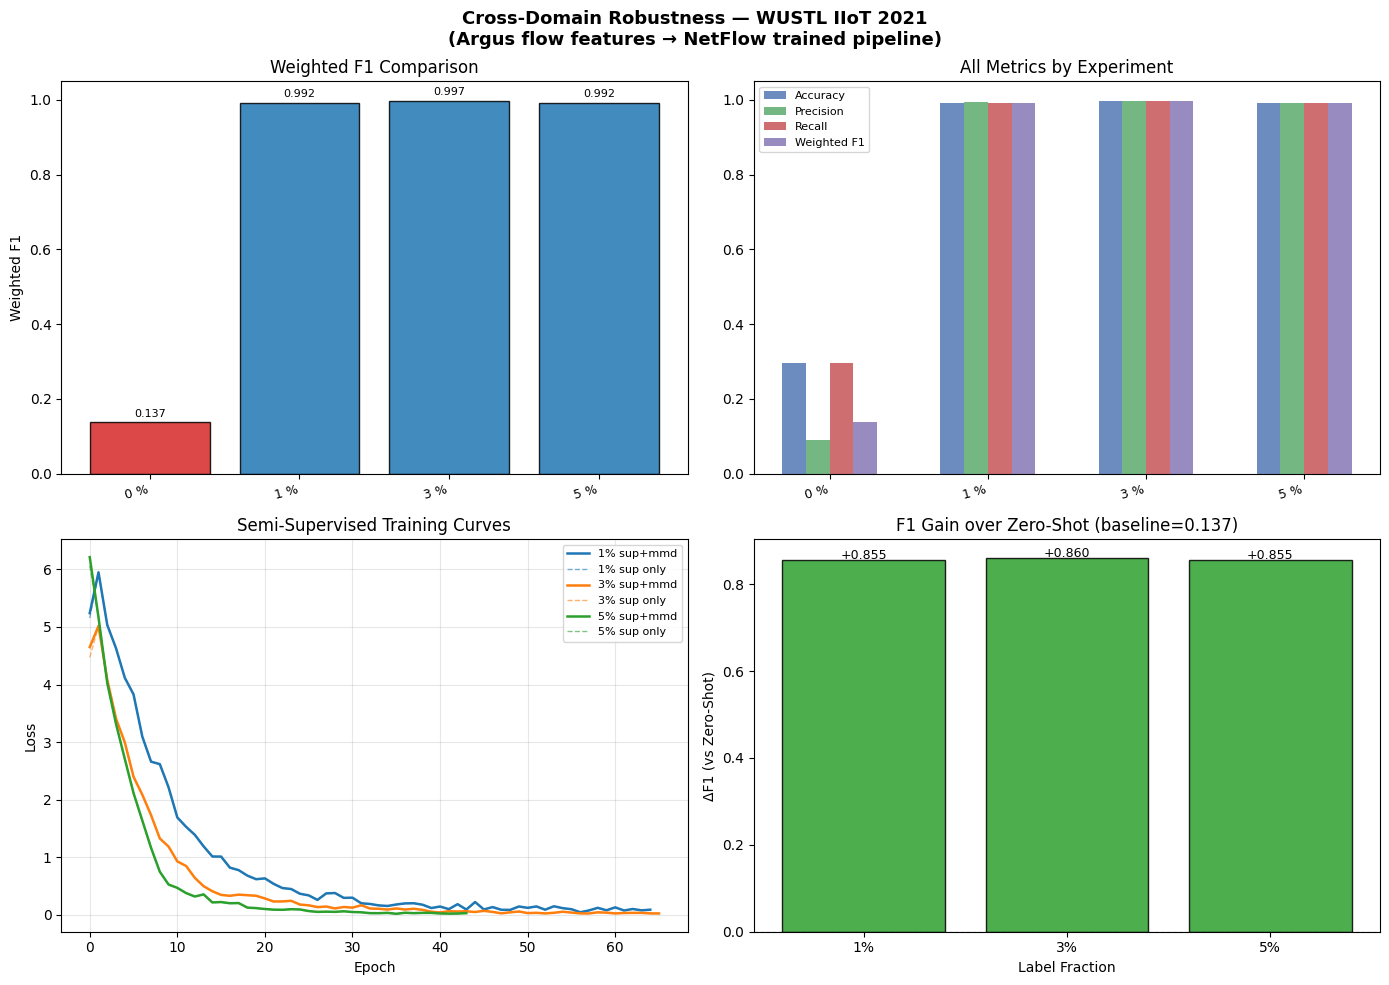

✓ Dashboard saved.


In [11]:
# ================================================================
# Dashboard Visualization
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Cross-Domain Robustness — WUSTL IIoT 2021\n(Argus flow features → NetFlow trained pipeline)',
    fontsize=13, fontweight='bold'
)
color_map = {
    'Accuracy'   : '#4C72B0',
    'Precision'  : '#55A868',
    'Recall'     : '#C44E52',
    'Weighted F1': '#8172B2',
}
labels_x = summary_df['Labels used'].tolist()
x_pos    = np.arange(len(labels_x))

# ── Top-left: F1 comparison bar ──────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x_pos, summary_df['Weighted F1'],
              color=['#d62728' if '0' in lx else '#1f77b4' for lx in labels_x],
              alpha=0.85, edgecolor='k')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_x, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Weighted F1')
ax.set_ylim(0, 1.05)
ax.set_title('Weighted F1 Comparison')
for bar, val in zip(bars, summary_df['Weighted F1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# ── Top-right: All metrics grouped bar ───────────────────────────
ax = axes[0, 1]
metric_cols = ['Accuracy', 'Precision', 'Recall', 'Weighted F1']
n_metrics   = len(metric_cols)
width       = 0.15
for j, metric in enumerate(metric_cols):
    off = (j - n_metrics / 2 + 0.5) * width
    vals = summary_df[metric].values
    ax.bar(x_pos + off, vals, width=width, label=metric,
           alpha=0.82, color=list(color_map.values())[j])
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_x, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title('All Metrics by Experiment')
ax.legend(fontsize=8)

# ── Bottom-left: Semi-supervised training curves ─────────────────
ax = axes[1, 0]
colors_frac = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (frac, res), col in zip(semi_results.items(), colors_frac):
    hist = res.get('history', {})
    if hist.get('total'):
        ax.plot(hist['total'], label=f'{frac*100:.0f}% sup+mmd',
                color=col, linewidth=1.8)
        ax.plot(hist['sup'], label=f'{frac*100:.0f}% sup only',
                color=col, linewidth=1.0, linestyle='--', alpha=0.6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Semi-Supervised Training Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Bottom-right: Improvement over zero-shot ─────────────────────
ax = axes[1, 1]
base_f1 = r0.get('f1', 0.0)
frac_labels = [f'{frac*100:.0f}%' for frac in LABEL_FRACTIONS]
improvements = [
    all_results.get(f'semi_{int(frac*100)}pct', {}).get('f1', 0.0) - base_f1
    for frac in LABEL_FRACTIONS
]
bar_colors = ['#2ca02c' if v > 0 else '#d62728' for v in improvements]
ax.bar(frac_labels, improvements, color=bar_colors, alpha=0.85, edgecolor='k')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('Label Fraction')
ax.set_ylabel('ΔF1 (vs Zero-Shot)')
ax.set_title(f'F1 Gain over Zero-Shot (baseline={base_f1:.3f})')
for i, val in enumerate(improvements):
    ax.text(i, val + (0.003 if val >= 0 else -0.008),
            f'{val:+.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(WUSTL_DATA_PATH),
                         'wustl_cross_domain_results.png'), dpi=120)
plt.show()
print("✓ Dashboard saved.")

In [12]:
# ================================================================
# Save Results
# ================================================================
import json, datetime

results_dir = os.path.join(os.path.dirname(WUSTL_DATA_PATH), 'wustl_results')
os.makedirs(results_dir, exist_ok=True)

# ── CSV table ────────────────────────────────────────────────────
csv_path = os.path.join(results_dir, 'wustl_test_results.csv')
summary_df.to_csv(csv_path)
print(f"✓ CSV saved: {csv_path}")

# ── JSON (serialisable metrics only) ─────────────────────────────
def to_serialisable(d):
    out = {}
    for k, v in d.items():
        if isinstance(v, float):
            out[k] = round(v, 6)
        elif isinstance(v, (int, str)):
            out[k] = v
    return out

json_payload = {
    'timestamp'     : datetime.datetime.now().isoformat(),
    'dataset'       : 'WUSTL IIoT 2021',
    'feature_space' : f'Argus flow ({WUSTL_N_FEATURES} features)',
    'train_domain'  : 'UQ-NIDS-v3 (47 NetFlow features)',
    'classes'       : [le.inverse_transform([i])[0] for i in WUSTL_PRESENT_CLASSES],
    'n_eval_samples': int(len(wustl_y_eval)),
    'results'       : {k: to_serialisable(v)
                       for k, v in all_results.items()
                       if isinstance(v, dict)},
}
json_path = os.path.join(results_dir, 'wustl_test_results.json')
with open(json_path, 'w') as f:
    json.dump(json_payload, f, indent=2)
print(f"✓ JSON saved: {json_path}")

# ── Best extractor state ─────────────────────────────────────────
best_frac = max(LABEL_FRACTIONS,
                key=lambda f: semi_results.get(f, {}).get('f1', 0.0))
best_ext  = semi_results[best_frac]['extractor']
ext_path  = os.path.join(results_dir,
                          f'wustl_extractor_semi{int(best_frac*100)}pct.pth')
torch.save(best_ext.state_dict(), ext_path)
print(f"✓ Best extractor saved: {ext_path}")

print("\n" + "="*55)
print("  All results saved successfully.")
print("="*55)

✓ CSV saved: /home/huyho/earth_predict_env/Dataset/wustl_results/wustl_test_results.csv
✓ JSON saved: /home/huyho/earth_predict_env/Dataset/wustl_results/wustl_test_results.json
✓ Best extractor saved: /home/huyho/earth_predict_env/Dataset/wustl_results/wustl_extractor_semi5pct.pth

  All results saved successfully.
